# Configurações e coleta de dados

In [25]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Carregar o dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')

# Fase 1: Análise Exploratória de Dados (EDA)

## Descritiva e Estatística

In [26]:
# Exibir informações estruturais
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")

# Exibir tipos de dados
print("\nTipos de dados de cada variável:")
print(df.dtypes)

# Exibir sumário estatístico
print("\nSumário estatístico descritivo:")
print(df.describe())

Total de linhas: 32581
Total de colunas: 12

Tipos de dados de cada variável:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Sumário estatístico descritivo:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000

## Visual

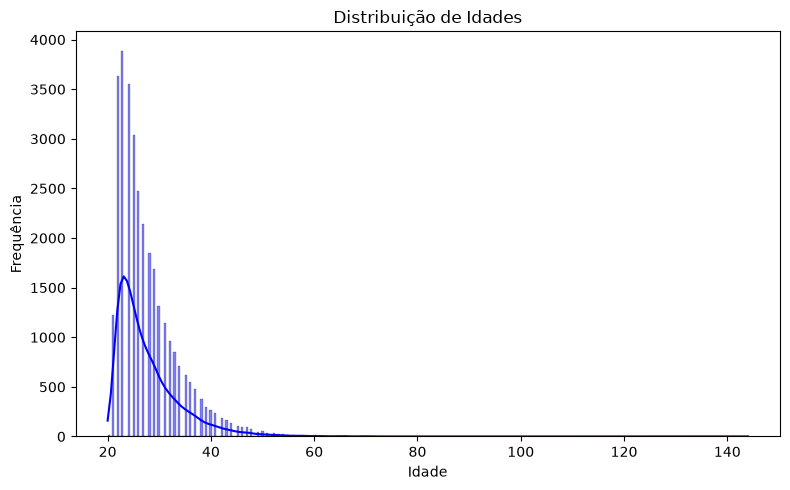

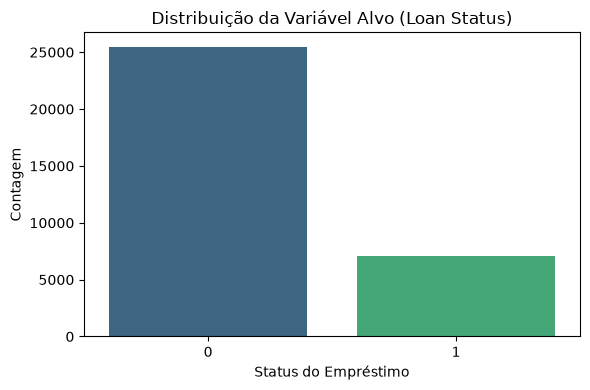

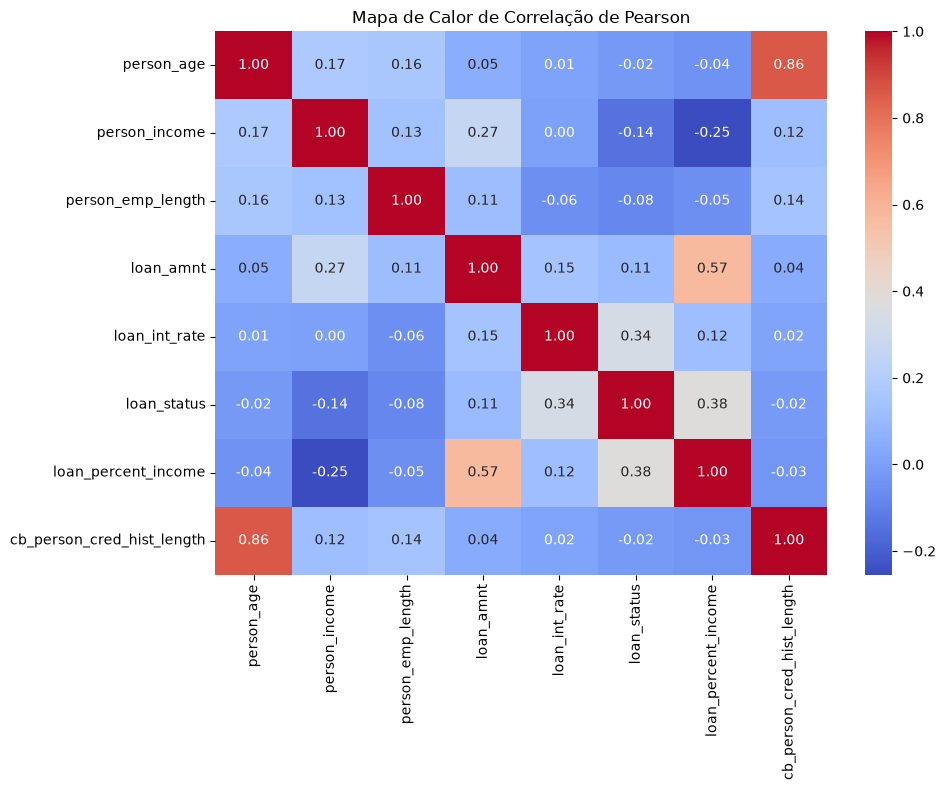

In [27]:
# 1. Histograma de Distribuição de Idades
plt.figure(figsize=(8, 5))
sns.histplot(df['person_age'], kde=True, color='blue')
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# 2. Gráfico de Barras: Desbalanceamento da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, hue='loan_status', palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (Loan Status)')
plt.xlabel('Status do Empréstimo')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show() # Exibe o gráfico diretamente na saída do notebook

# 3. Mapa de Calor de Correlação (Pearson)
plt.figure(figsize=(10, 8))
# Seleciona apenas colunas numéricas para calcular a correlação de Pearson
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlação de Pearson')
plt.tight_layout()
plt.show()

## Tomada de Decisão

A análise revelou que o dataset exige uma limpeza rigorosa. Primeiramente, é necessário remover ou corrigir os registros com idades e tempos de emprego irreais para garantir a sanidade estatística. Os valores nulos em loan_int_rate e person_emp_length serão tratados. Devido ao desbalanceamento visualizado na variável alvo, a estratégia de preparação incluirá técnicas de reamostragem ou ajuste de pesos na modelagem, para que o algoritmo não desenvolva um viés excessivo em favor da classe majoritária, garantindo a eficácia na detecção de fraudes ou calotes.

# Fase 2 : Tratamento e Limpeza (DATA PREP)

# Tratamento de Duplicadas

In [28]:
# Justificativa: A remoção de linhas duplicadas é essencial para evitar redundância.
df.drop_duplicates(inplace=True)
print("Linhas duplicadas removidas com sucesso.")

Linhas duplicadas removidas com sucesso.


# Tratamento de Valores Nulos

Justificativa: Utilizamos a Mediana para preencher valores ausentes nas colunas 'person_emp_length' e 'loan_int_rate'. Mediana é mais robusta, garantindo que o valor inserido seja estatisticamente representativo da tendência central dos dados.

In [35]:

colunas_nulas = ['person_emp_length', 'loan_int_rate']

for col in colunas_nulas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

print("Valores nulos tratados com a mediana.")

Valores nulos tratados com a mediana.


## Tratamento de Outliers

Justificativa: Identificamos valores irreais (outliers) via análise visual prévia. Optamos pela técnica de Clipping (limitação), que substitui valores extremos pelos limites calculados. Esta técnica preserva o volume da base de dados e é crucial para modelos como KNN, que calculam distâncias euclidianas e são altamente sensíveis a valores distorcidos.

In [36]:
def tratar_outliers_clipping(df, colunas):
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)
    return df

colunas_outliers = ['person_age', 'person_emp_length', 'loan_amnt']
df = tratar_outliers_clipping(df, colunas_outliers)
print("Outliers tratados via clipping.")

Outliers tratados via clipping.
